# Tutoral: CN7050: Intelligent Systems

## LLM Powered Atonomus Agents
The tutorial cover the steps for Building a Web Search Agent


Prepared by:

Dr Shaheen Khatoon

Ph.D. | PMP | PMI-ACP | ITIL | PgCert TLHE

Senior Lecturer in Data Science (Computer Science and Digital Technologies)
School of Architecture, Computing and Engineering

 Room: EB.1.99

(e) S.Khatoon@uel.ac.uk

(w) https://uel.ac.uk/about-uel/staff/shaheen-khatoon
'''

**NOTE:** LLM will take long time to load and run, be patient and just understand the logical flow. You may try with other smaller open source or paid LLM to avoid such problems.

Also the libraries are quickly changing and some might not work. In that case find alternatives by doing some resaerch.

# Installing Required Libraries

In [ ]:
#!pip install langchain langchain-huggingface huggingface-hub  duckduckgo-search
!pip install -q langchain langchain-huggingface huggingface-hub duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.1 MB/s eta 0:00:00


In [ ]:
!pip install -q transformers sentence-transformers accelerate

In [ ]:
!pip install -q html2text faiss-cpu streamlit chromadb langchain-community

In [ ]:
!pip  -q install requests==2.32.4

In [ ]:
!pip install -q numexpr youtube_search wikipedia

  Preparing metadata (setup.py) ... done


In [ ]:
#!pip install accelerate

In [ ]:
!pip install -q bitsandbytes git+https://github.com/huggingface/transformers.git

In [ ]:
!pip -q install langchain-huggingface

In [ ]:
!pip install -q -U ddgs

# Improrting Libraries

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain.agents import load_tools
from langchain.agents import initialize_agent
import pandas as pd

# Representation of an LLM agent’s system for internet research
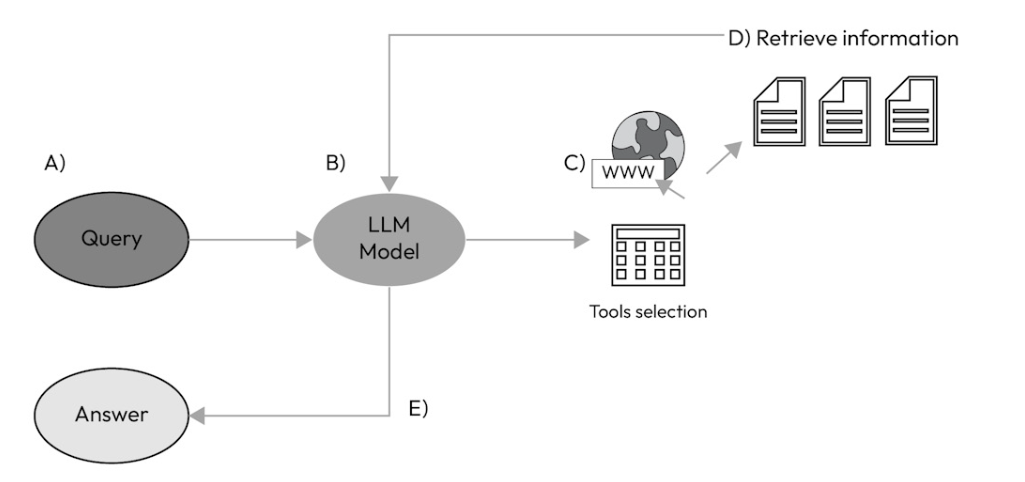


Let’s break down Figure:

The user formulates a query.

The model analyzes the query and plans actions to solve the task.

The appropriate tool (in this case, internet search) is selected.

Documents are identified during the internet search. The information is sent back to the model, which analyzes it and decides whether further action is required or whether the task is accomplished.

The model generates the answer, which is sent back to the user.

## LangChain
LangChain allows the LLM to be able to connect to the web through the use of **tools**.

In general, the most widely used approach is known as Reasoning and Acting (ReAct) prompting. During the first stage (reasoning), the model considers the best strategy to be able to arrive at the answer, and in the second stage (acting), it executes the plan. In this approach, the model also tracks the reasoning steps and can guide it to the solution. This approach also allows flexibility because it enables the model to mold the prompt to its needs.


LangChain offers a number of tools that are designed to extend the model and find the information it needs.

For example, it offers several tools for searching the internet. The DuckDuckGo tool allows people to use the DuckDuckGo search engine.

This search engine is free and does not track user data (it also filters out pages that are full of advertising or have articles written only to rank highly in the Google search engine).

In order to use it, we need to install a specific Python library and then import the tool into LangChain:

In [ ]:
from langchain.tools import DuckDuckGoSearchRun

ddg_search = DuckDuckGoSearchRun()
ddg_search.run('Who is the current president of Italy?')

"The president of Italy , officially titled President of the Italian Republic, is the head of state of Italy . In that role, the president represents national unity and guarantees that Italian politics comply with the Constitution. Italy : Italy has a diversified economy, ranking as the third-largest in the Eurozone by GDP. Italy is a parliamentary republic, hence the President of the Republic's role is mostly cerimonial. He is the chief of state and is indirectly elected for a 7-year term. current progress 0%.The Italian president , who wields strong moral authority as head of state, has not made any public comment on the Starlink deal or the choices facing Italy as it seeks to enlist a satellite-based internet provider. Is Laura Mattarella the most influential Italian you've never heard of?It seems navy blue is a favourite colour for the First Lady of Italy , who wore a sculptured off-the-shoulder indigo ballgown to meet the King and Queen of Spain in 2024. Italy is a strategic partn

# Defining Search Tool
One of the strengths of LangChain is the ability to build a **list of tools** that can then be used by the LLM.

To do this, we have to give a name, explain what the function to be performed is, and provide a description.

This way, the LLM is informed about what tool it can use when it has to do an internet search:

##Defining DuckDuckGo Search

In [ ]:
#Creating DuckDuckGo Search
from langchain.agents import Tool

tools = [
   Tool(
       name="DuckDuckGo Search",
       func=ddg_search.run,
       description="A web search tool to extract information from Internet.",
   )
]

## Using Google search engine
It is possible to use Google Serper, a low-cost API (albeit with some limitations) that enables you to use the Google search engine (you have to register at https://serper.dev/ to get an API key); however, there is a fee for the service.
In fact, the Google API is much more expensive and the LLM cannot access directly the search engine (Serper allows us to use the Google search engine through their API, and they provide some free credits):

In [ ]:
#!pip install google-serp-api
#try by yorself
'''
import os
SERPER_API_KEY = 'your_key'
os.environ["SERPER_API_KEY"] = SERPER_API_KEY

from langchain.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

tools.append(
   Tool(
       name="Google Web Search",
       func=google_search.run,
       description="Google search tool to extract information from Internet.",
   )
)
'''

##Using Wikipedia
Additionally, we can add Wikipedia as a reliable source of information:

In [ ]:
from langchain.tools import WikipediaQueryRun
from langchain.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

tools.append(
   Tool(
       name="Wikipedia Web Search",
       func=wikipedia.run,
       description="Useful tool to search Wikipedia.",
   )
)

# Create and Run Agent
Once we have the various tools, we can then initialize an agent and conduct a query:

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline
from langchain.agents import load_tools
from langchain.agents import initialize_agent
import torch

## Setting Up the Language Model

In [ ]:
model_id = "microsoft/Phi-3-mini-4k-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)


# Define the BitsAndBytesConfig for 4-bit quantization
# Quantization makes it feasible to load large models (like 7B) even on Colab GPUs with 16 GB VRAM.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    #attn_implementation="flash_attention_2", # if you have an ampere GPU
)

# Define the text generation pipeline using HuggingFace transformers
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=200, top_k=50, temperature=0.1) # increase token size if high end GPU

# Wrap the pipeline in a HuggingFacePipeline object
llm = HuggingFacePipeline(pipeline=pipe)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

## Create Agent

In [ ]:
agent = initialize_agent(
   tools, llm, agent="zero-shot-react-description", verbose=True,
    handle_parsing_errors=True,
    max_iterations=1,
)

## Run Agent

In [ ]:
# Define the query
query = "Who is the current president of Italy? Who was the previous one?"

# Execute the agent query
response = agent.run(query)
print(response)



> Entering new AgentExecutor chain...
Parsing LLM output produced both a final answer and a parse-able action:: Answer the following questions as best you can. You have access to the following tools:

Calculator(*args: Any, callbacks: Union[list[langchain_core.callbacks.base.BaseCallbackHandler], langchain_core.callbacks.base.BaseCallbackManager, NoneType] = None, tags: list[str] | None = None, metadata: dict[str, typing.Any] | None = None, **kwargs: Any) -> Any - Useful for when you need to answer questions about math.

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [Calculator]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: Who is the current presiden

## Lab Task

Modify the code to add query tempalte and explicit stop criteria

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline #Loads pre-trained large language models.
from langchain_huggingface import HuggingFacePipeline #Wraps the Hugging Face model for integration with LangChain’s framework.
from langchain.agents import load_tools, AgentExecutor, initialize_agent #Allow the model to call tools (like web search, Wikipedia, or a calculator).
from langchain_core.prompts import PromptTemplate #Controls how instructions and responses are formatted

# Load the model and tokenizer
#model_id = "meta-llama/Meta-Llama-3-8B-Instruct" #requires login and secret key
#model_id="HuggingFaceH4/zephyr-7b-beta" # take long time

model_id = "microsoft/Phi-3-mini-4k-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)

# Define the BitsAndBytesConfig for 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

#Load Model with Quantization

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
)
#Loads the causal language model (for text generation tasks).

# Quantization makes it feasible to load large models (like 7B) even on Colab GPUs with 16 GB VRAM.


# Define the text generation pipeline using HuggingFace transformers
pipe = pipeline("text-generation", model=model,
                tokenizer=tokenizer, max_new_tokens=200,
                top_k=50, temperature=0.1,
               do_sample=True)

# Wrap the pipeline in a HuggingFacePipeline object
llm = HuggingFacePipeline(pipeline=pipe)
#Wraps the Hugging Face pipeline into a LangChain-compatible model interface.

# Load the necessary tools
# tools = load_tools(["ddg-search",  "llm-math", "wikipedia"], llm=llm) # try this but will long time

tools = load_tools(["llm-math"], llm=llm) #for simplicity

# Define the prompt template with explicit stop instructions
template = '''Answer the following question as best as you can. You have access to the following tools:

{tools}

Use the following format:

Question: {input}
Thought: You should think about what action to take
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Do not answer or ask any other questions. Stop once you have provided the Final Answer.


Begin!

Question: {input}
'''

# Create a PromptTemplate from the template
prompt = PromptTemplate.from_template(template)

# Initialize the agent using initialize_agent
agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent="zero-shot-react-description", #Uses reasoning + tool use to find answers.
    prompt=prompt,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=1,
    stop_sequence="Final Answer:"
)

# Define the query
query = "The biography of Napoleon"

# Execute the query
response = agent.run(query)

#response = llm.invoke(query) # skip tools and only use models
print(response)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]



> Entering new AgentExecutor chain...
Parsing LLM output produced both a final answer and a parse-able action:: Answer the following questions as best you can. You have access to the following tools:

Calculator(*args: Any, callbacks: Union[list[langchain_core.callbacks.base.BaseCallbackHandler], langchain_core.callbacks.base.BaseCallbackManager, NoneType] = None, tags: list[str] | None = None, metadata: dict[str, typing.Any] | None = None, **kwargs: Any) -> Any - Useful for when you need to answer questions about math.

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [Calculator]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: The biography of Napoleon
T

## Lab Tasks
Modify the code by searching other open acees light weight models

however, it will take long time to excute:


Phi-3-mini-4k-instruct -- free and smallest to use

Qwen-7B-instruct

Mamba-7B-rw

Meta-Llama-3-8B-instruct

model_id = "meta-llama/Meta-Llama-3-8B-Instruct" #requires login and secret key

model_id="HuggingFaceH4/zephyr-7b-beta"# requires login and approval hugingface


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain.agents import load_tools
from langchain.agents import initialize_agent
model_id = "mistralai/Mistral-7B-Instruct-v0.1" # try different model here, howver, execution will take long time
tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    load_in_4bit=True,
    #attn_implementation="flash_attention_2", # if you have an ampere GPU
)

Saving in drive and creating HTML